# 03 · Feature Engineering & Feature Selection

**Notebook:** 03 of 04  

**Goal:** Engineer domain-driven features, handle skewness, select important features, and prepare both a modeling DataFrame and a deployment DataFrame.

### What this notebook covers
- Apply feature creation to enhanse model learning 
- Log transforms for skewed features for created features (Total Income, Loan Amount)
- Prepare two DataFrames: `df` for modeling (Contain log columns), `df_streamlit` for deployment (raw columns)
- apply Feature selection: Pearson correlation + ExtraTreesClassifier 
- Drop low-importance features
- Save both DataFrames for modeling and deployment step

In [132]:
import plotly.express as px
import pandas as pd
import numpy as np

# for plotly visualizations in SVG format for github
import plotly.io as pio
pio.renderers.default = 'svg'

In [133]:
# ── Load EDA data from notebook 3 ───────────────────────────────────────────
df = pd.read_csv("/Users/mohammedmahmood/Desktop/Fresco/files/data/02_eda_clean.csv")
print(f"Loaded → shape: {df.shape}")
df.head(3)

Loaded → shape: (614, 15)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,log_ApplicantIncome,log_LoanAmount,Total_Income
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y,8.674026,NaN,5849.0
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,8.430109,4.852030,6091.0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,8.006368,4.189655,3000.0


# Feature Engineering

### 1- Total Income ( created in bivariate analysis we will check it's distribution & handle outliers )

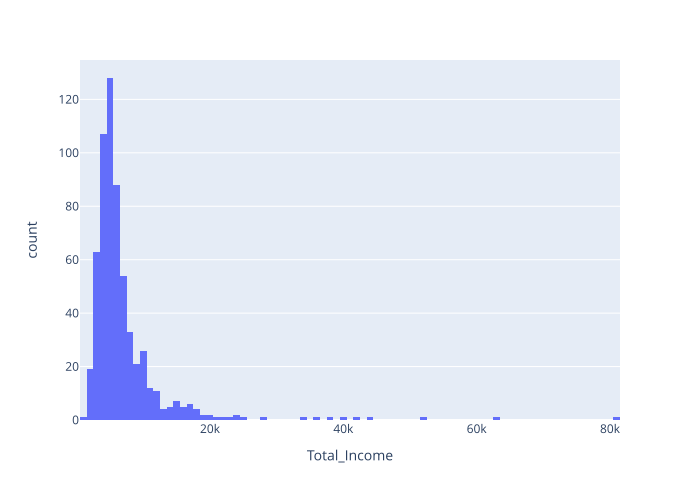

In [134]:
fig = px.histogram(df, x= "Total_Income")

fig.show()

In [135]:
# take log for Total_Income  to handle skewness
df["log_Total_Income"] = np.log(df["Total_Income"])

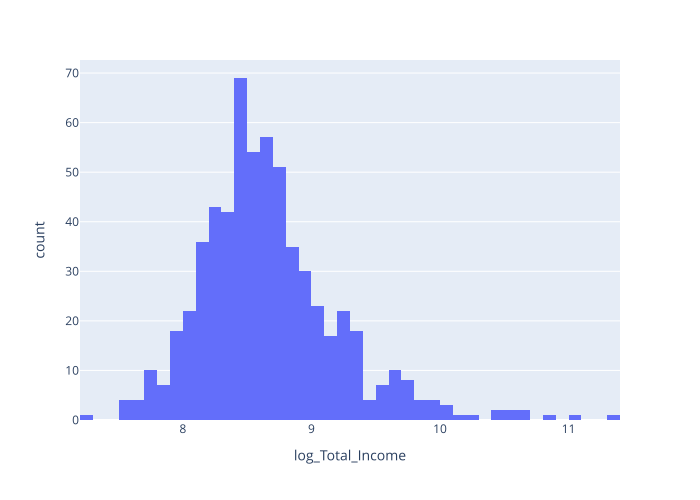

In [136]:
fig = px.histogram(df, x= "log_Total_Income")

fig.show()

In [137]:
from datasist.structdata import detect_outliers

idx = detect_outliers(df, 0, ['log_Total_Income'])
len(idx)

22

### **Taking the log of the column helps handle skewness and outliers**

## 2- Loan Monthly Paid

In [138]:
df.Loan_Amount_Term.unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [139]:
df.LoanAmount.describe()

count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64

In [140]:
df["Loan_Monthly_Paid"] = round((df["LoanAmount"] * 1000 ) / (df["Loan_Amount_Term"]) , 2 )

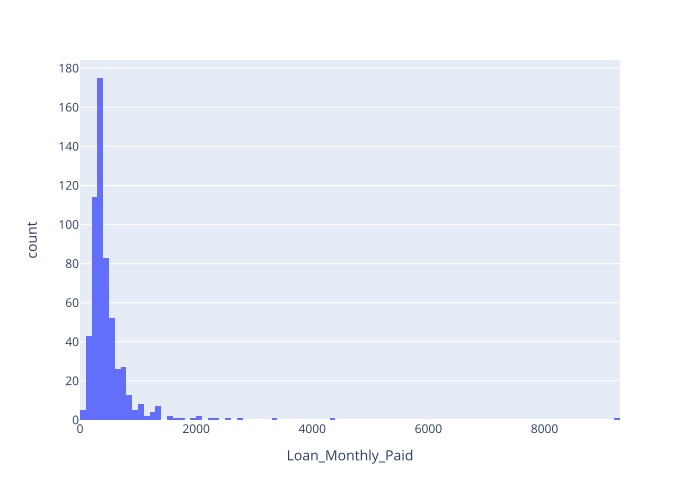

In [141]:
fig = px.histogram(df, x="Loan_Monthly_Paid")

fig.show()

In [142]:
from datasist.structdata import detect_outliers

idx = detect_outliers(df, 0, ['Loan_Monthly_Paid'])
len(idx)

0

In [143]:
df["log_Loan_Monthly_Paid"] = np.log(df["Loan_Monthly_Paid"])

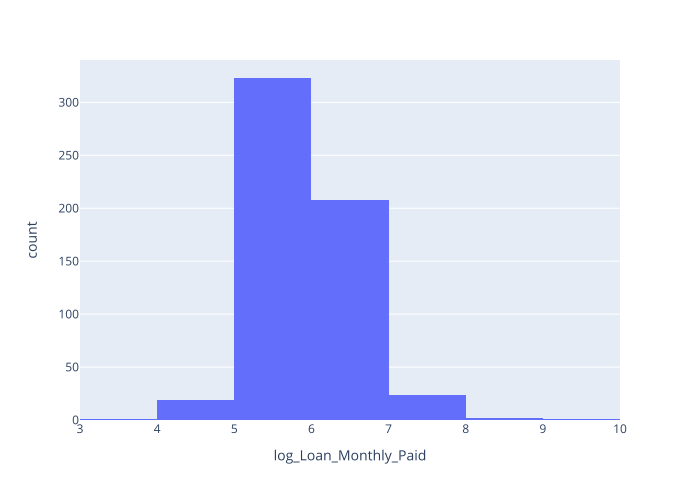

In [144]:
fig = px.histogram(df, x= "log_Loan_Monthly_Paid")

fig.show()

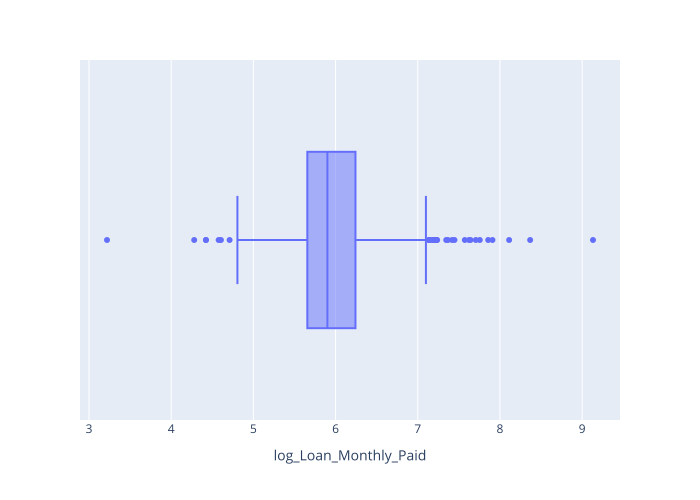

In [145]:
fig = px.box(df, x= "log_Loan_Monthly_Paid" )

fig.show()

In [146]:
from datasist.structdata import detect_outliers

idx = detect_outliers(df, 0, ['log_Loan_Monthly_Paid'])
len(idx)

0

## 3- Income After Loan

In [147]:
df[["ApplicantIncome", "Loan_Monthly_Paid"]]

,ApplicantIncome,Loan_Monthly_Paid
0,5849,NaN
1,4583,355.56
2,3000,183.33
3,2583,333.33
4,6000,391.67
...,...,...
609,2900,197.22
610,4106,222.22
611,8072,702.78
612,7583,519.44


In [148]:
df["Income_After_Loan"] = df["ApplicantIncome"] - df["Loan_Monthly_Paid"]

In [149]:
df.Income_After_Loan.describe()

count      578.000000
mean      4954.838651
std       6079.757247
min      -4625.000000
25%       2467.440000
50%       3422.890000
75%       5208.750000
max      80000.000000
Name: Income_After_Loan, dtype: float64

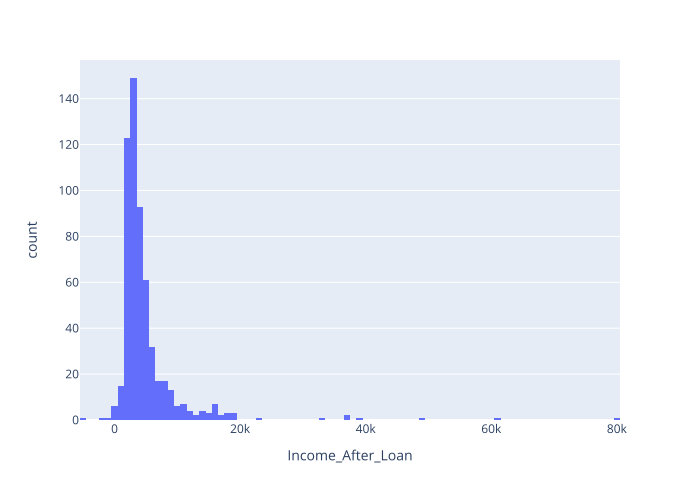

In [150]:
fig = px.histogram(df, x= "Income_After_Loan")
fig.show()

In [151]:
from datasist.structdata import detect_outliers

idx = detect_outliers(df, 0, ['Income_After_Loan'])
len(idx)

0

In [152]:
# take the log if the columns to handle skewness
df["log_Income_After_Loan"] = np.log(df["Income_After_Loan"])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning:

invalid value encountered in log



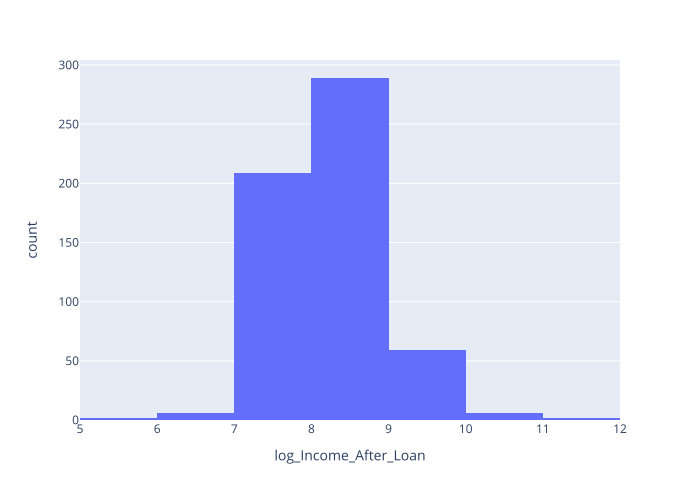

In [153]:
fig = px.histogram(df, x= "log_Income_After_Loan")
fig.show()


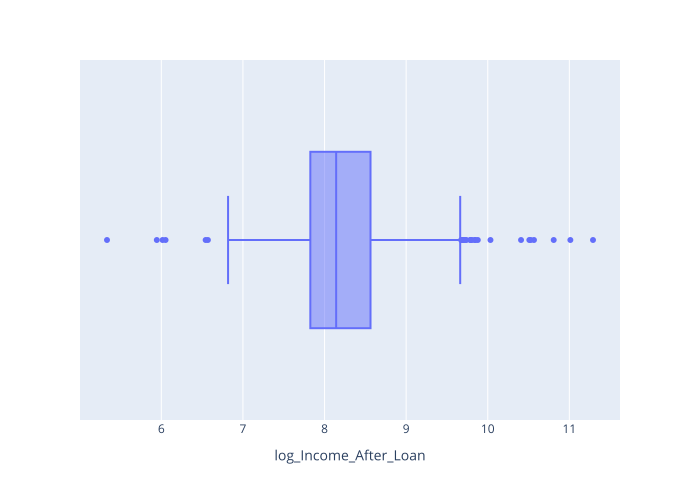

In [154]:
fig = px.box(df, x= "log_Income_After_Loan" )
fig.show()

In [155]:
idx = detect_outliers(df, 1, ['log_Income_After_Loan' ])
len(idx)

0

## 4-Income_to_LoanRatio

In [156]:
df['Income_to_LoanRatio'] = (df['Total_Income'] / df['LoanAmount'].replace(0, np.nan)).round(2)

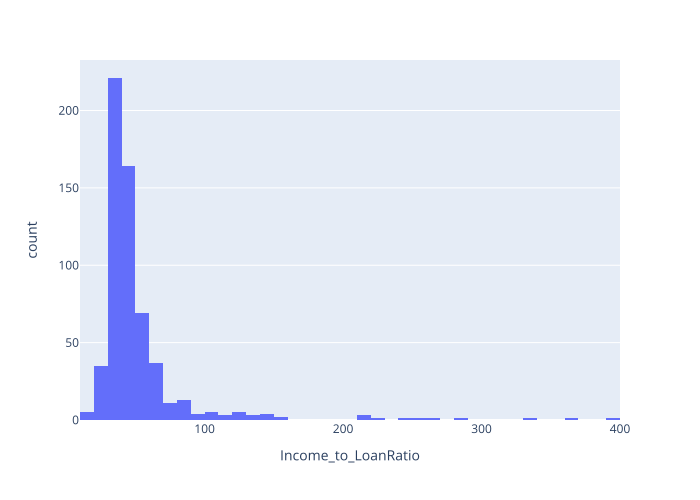

In [157]:
fig = px.histogram(df, x= "Income_to_LoanRatio")

fig.show()

In [158]:
df["log_Income_to_LoanRatio"] = np.log(df["Income_to_LoanRatio"])

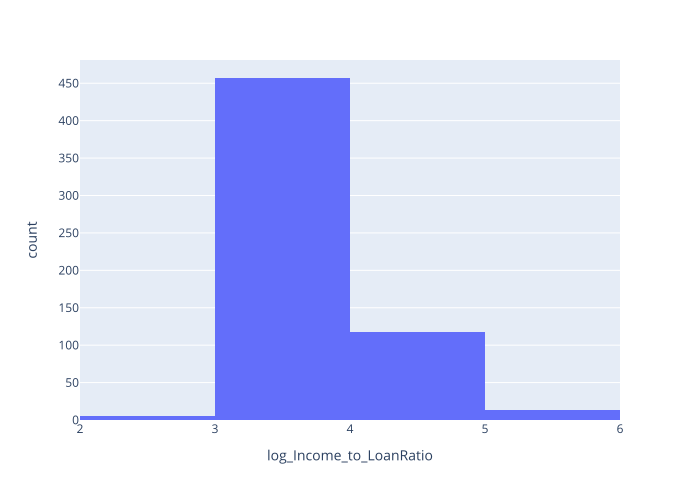

In [159]:
fig = px.histogram(df, x= "log_Income_to_LoanRatio")
fig.show()



In [160]:
df_streamlit= df.copy()

In [161]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'log_ApplicantIncome', 'log_LoanAmount', 'Total_Income',
       'log_Total_Income', 'Loan_Monthly_Paid', 'log_Loan_Monthly_Paid',
       'Income_After_Loan', 'log_Income_After_Loan', 'Income_to_LoanRatio',
       'log_Income_to_LoanRatio'],
      dtype='object')

## **1. Production dataframe (contain columns without log for deployment )**

In [162]:
df_streamlit.drop(['Loan_Amount_Term', 'log_ApplicantIncome', 'log_LoanAmount', 'log_Total_Income', 'Loan_Monthly_Paid', 'log_Loan_Monthly_Paid', 'log_Income_After_Loan', "log_Income_to_LoanRatio" ] , axis = 1 , inplace = True)

##  **2. Modeling and main dataframe (contain log columns that will using in modelling)**

In [163]:
# drop the original columns
df.drop(['ApplicantIncome', 'CoapplicantIncome', 'Total_Income', 'Loan_Monthly_Paid', 'Income_After_Loan', "LoanAmount", "Income_to_LoanRatio"] , axis = 1 , inplace = True)

### **outliers after all handling (We can see that the number of outliers has decreased after handling them)**

## Check outliers 

In [164]:
from datasist.structdata import detect_outliers


DF = df.select_dtypes(include="number")

for col in DF.columns:
    outliers = detect_outliers(df, 0, [col])
    print(f"{col}: {len(outliers)} outliers")


Loan_Amount_Term: 0 outliers
Credit_History: 0 outliers
log_ApplicantIncome: 27 outliers
log_LoanAmount: 0 outliers
log_Total_Income: 22 outliers
log_Loan_Monthly_Paid: 0 outliers
log_Income_After_Loan: 0 outliers
log_Income_to_LoanRatio: 0 outliers


In [165]:
# Map Target column 
df["Loan_Status"] = df["Loan_Status"].map({"N" : 0, "Y": 1})

### **outliers after all handling (We can see that the number of outliers has decreased after handling them)**

# Feature Importance

## 1- Check Correlation

In [166]:
corr = df.select_dtypes(include="number")
corr = corr.corr()['Loan_Status'].sort_values(ascending=False)
print(corr)

Loan_Status                1.000000
Credit_History             0.561678
log_Income_to_LoanRatio    0.049036
log_ApplicantIncome        0.010977
log_Total_Income           0.007240
log_Income_After_Loan     -0.006132
Loan_Amount_Term          -0.021268
log_Loan_Monthly_Paid     -0.031284
log_LoanAmount            -0.039100
Name: Loan_Status, dtype: float64


## 2- **ExtraTreesClassifier**

### - Feature Importance Analysis by ExtraTreesClassifier -

**This script prepares feature and evaluates feature importance
using an ExtraTreesClassifier**

Why ExtraTrees:
----------------
ExtraTrees (Extremely Randomized Trees) is a tree-based ensemble method that:
- Handles both numerical and categorical inputs after encoding.
- Is resistant to noise and outliers.
- Provides reliable estimates of feature importance, guiding feature selection
  and model refinement.


Key Steps:
------------

1. **Encode categorical features:**
   - Map 'International_plan' and 'Voice_mail_plan' (Yes/No → 1/0).
   - Use Binary Encoding for 'State' (too many categories for One-Hot).

2. **Combine encoded categorical and numeric usage features.**

3. **Train ExtraTreesClassifier:**
   - Robust to outliers, no scaling needed.
   - Provides reliable feature importance.

4. **Extract and sort feature importance to identify key drivers of churn.**


## ------------------------- This explain coming code--------------------------

In [167]:
df_importance = df.copy()

In [168]:
df_importance.dropna(inplace= True)

In [169]:
df_Cat = df.select_dtypes(include="object")

for col in df_Cat.columns :
    print(f"Column {col} has {df_Cat[col].nunique()} values")


Column Gender has 2 values
Column Married has 2 values
Column Dependents has 4 values
Column Education has 2 values
Column Self_Employed has 2 values
Column Property_Area has 3 values


In [170]:
df.select_dtypes(include= "number").columns

Index(['Loan_Amount_Term', 'Credit_History', 'Loan_Status',
       'log_ApplicantIncome', 'log_LoanAmount', 'log_Total_Income',
       'log_Loan_Monthly_Paid', 'log_Income_After_Loan',
       'log_Income_to_LoanRatio'],
      dtype='object')

In [171]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import ExtraTreesClassifier

cat_cols = [ 'Gender', 'Married', 'Education', "Self_Employed", "Property_Area", 'Dependents' ]

num_cols = ['Loan_Amount_Term', 'Credit_History',
       'log_ApplicantIncome', 'log_LoanAmount', 'log_Total_Income',
       'log_Loan_Monthly_Paid', 'log_Income_After_Loan',
       'log_Income_to_LoanRatio']


for col in cat_cols:
    le = LabelEncoder()
    df_importance[col] = le.fit_transform(df_importance[col].astype(str))


X = df_importance[cat_cols + num_cols]
y = df_importance['Loan_Status']

In [172]:
# Fit ExtraTreesClassifier
model = ExtraTreesClassifier()
model.fit(X, y)

#  Get feature importances
importances = pd.Series(model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

#  Show top features
importances_sorted

Credit_History             0.257542
log_Income_to_LoanRatio    0.093325
log_Income_After_Loan      0.089543
log_LoanAmount             0.088932
log_ApplicantIncome        0.088908
log_Loan_Monthly_Paid      0.086787
log_Total_Income           0.086184
Property_Area              0.044491
Dependents                 0.042993
Loan_Amount_Term           0.036591
Married                    0.021909
Education                  0.021225
Self_Employed              0.021213
Gender                     0.020357
dtype: float64

In [173]:
df.drop(["Education", "Self_Employed", "Gender"], inplace= True, axis= 1 )


In [174]:
df_streamlit.drop(["Education", "Self_Employed", "Gender"], inplace= True, axis= 1 )

In [175]:
df.duplicated().sum()

1

In [176]:
df.drop_duplicates(inplace= True)
df.reset_index(drop= True, inplace= True)

### **Check number of categorical and numerical null value to handle by Ml pipeline**

In [177]:
Cat_Columns = df.select_dtypes(include = "object")
Cat_Columns.isna().sum()

Married           3
Dependents       15
Property_Area     0
dtype: int64

In [178]:
Num_Columns = df.select_dtypes(include="number")
Num_Columns.isna().sum() 

Loan_Amount_Term           14
Credit_History             50
Loan_Status                 0
log_ApplicantIncome         0
log_LoanAmount             22
log_Total_Income            0
log_Loan_Monthly_Paid      36
log_Income_After_Loan      41
log_Income_to_LoanRatio    22
dtype: int64

In [179]:
# ── Save modeling and deployment DataFrames for notebook 04 ──────────────────
import os
os.makedirs("data", exist_ok=True)
df.to_csv("data/03_features_model.csv", index=False)

df_streamlit.to_csv("data/03_features_deploy.csv", index=False)
print(f"Saved modeling df   → data/03_features_model.csv  |  shape: {df.shape}")
print(f"Saved deployment df → data/03_features_deploy.csv |  shape: {df_streamlit.shape}")

Saved modeling df   → data/03_features_model.csv  |  shape: (613, 12)
Saved deployment df → data/03_features_deploy.csv |  shape: (614, 11)
